# 512 Simulation — Data Exploration & Visualisation

This notebook loads the 512-resolution simulation output with **ergane** and
provides an end-to-end interactive data exploration workflow:

| Section | What it does |
|---|---|
| **Setup** | Imports, paths, and `%matplotlib widget` backend |
| **Load data** | Build a `SimulationData` object |
| **Inspect** | Grid, physics, frame count, available fields |
| **Snapshot** | Static multi-panel plot for any single frame |
| **Time series** | Plot domain-averaged quantities vs. time |
| **Interactive viewer** | Scrub through all frames with a slider / Play button |

---
## 1 · Environment setup

In [1]:
# Use 'widget' backend for interactive plots (requires ipympl)
# Swap to 'inline' for static PNG output if ipympl is not installed.
%matplotlib widget

In [2]:
import os
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# ── Add project root to path so 'ergane' is importable ───────────────────────
PROJECT_ROOT = Path(os.path.abspath("..")).resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import ergane
from ergane import SimulationData, Visualization
from ergane.units import Units

print(f"ergane loaded from: {ergane.__file__}")
print(f"Project root     : {PROJECT_ROOT}")

ergane loaded from: /home/sasi/Projects/SubgridCGMModel/ergane/__init__.py
Project root     : /home/sasi/Projects/SubgridCGMModel


---
## 2 · Paths — edit these if your data lives elsewhere

In [3]:
# ── Configure your simulation paths here ─────────────────────────────────────
ATHINP_PATH = PROJECT_ROOT / "builds" / "hr_build" / "src" / "kh_radiative_128.athinput"
DATA_FOLDER  = PROJECT_ROOT / "simulation_outputs" / "hr_build"

print(f"athinput : {ATHINP_PATH}")
print(f"data dir : {DATA_FOLDER}")
print(f"athinput exists : {ATHINP_PATH.exists()}")
print(f"data dir exists : {DATA_FOLDER.exists()}")

athinput : /home/sasi/Projects/SubgridCGMModel/builds/hr_build/src/kh_radiative_128.athinput
data dir : /home/sasi/Projects/SubgridCGMModel/simulation_outputs/hr_build
athinput exists : True
data dir exists : True


---
## 3 · Load simulation data

In [4]:
sim = SimulationData(
    datafolder=DATA_FOLDER,
    athinp=ATHINP_PATH,
)
print(sim)

<SimulationData  basename='KH'  physics='hydro'  grid=(64×128)  n_frames=1001  units='CGS'>


---
## 4 · Inspect the simulation

In [5]:
# ── Basic metadata ────────────────────────────────────────────────────────────
print(f"Basename         : {sim.basename}")
print(f"Physics          : {sim.physics}")
print(f"Grid             : {sim.nx} × {sim.ny}  (nx × ny)")
print(f"Domain X         : [{sim.x1min:.3g}, {sim.x1max:.3g}]")
print(f"Domain Y         : [{sim.x2min:.3g}, {sim.x2max:.3g}]")
print(f"Adiabatic index γ: {sim.gamma}")
print(f"Total frames     : {sim.n_frames}")
print(f"Frame numbers    : {sim.frame_numbers[0]} … {sim.frame_numbers[-1]}")
print(f"Fields available : {sim.fields_available}")

Basename         : KH
Physics          : hydro
Grid             : 64 × 128  (nx × ny)
Domain X         : [-5, 5]
Domain Y         : [-10, 10]
Adiabatic index γ: 1.666667
Total frames     : 1001
Frame numbers    : 0 … 1000
Fields available : ['density', 'pressure', 'velx', 'vely', 'temperature']


In [6]:
# ── Time index (fast — reads only headers) ────────────────────────────────────
times = sim.times
print(f"Time range: t = {times[0]:.4f} → {times[-1]:.4f} (code units)")
print(f"Mean Δt   : {np.diff(times).mean():.4f}")

Time range: t = 0.0000 → 10.0000 (code units)
Mean Δt   : 0.0100


In [7]:
# ── Inspect the first frame ────────────────────────────────────────────────────
frame0 = sim.get_frame(sim.frame_numbers[0])
print(frame0)
print(f"  density shape : {frame0.density.shape if frame0.density is not None else 'N/A'}")
print(f"  pressure shape: {frame0.pressure.shape if frame0.pressure is not None else 'N/A'}")

<Frame #0  t=0.0000 [CGS]  fields=['density', 'pressure', 'temperature', 'velx', 'vely', 'velz']>
  density shape : (128, 64)
  pressure shape: (128, 64)


---
## 5 · Static snapshot — single frame

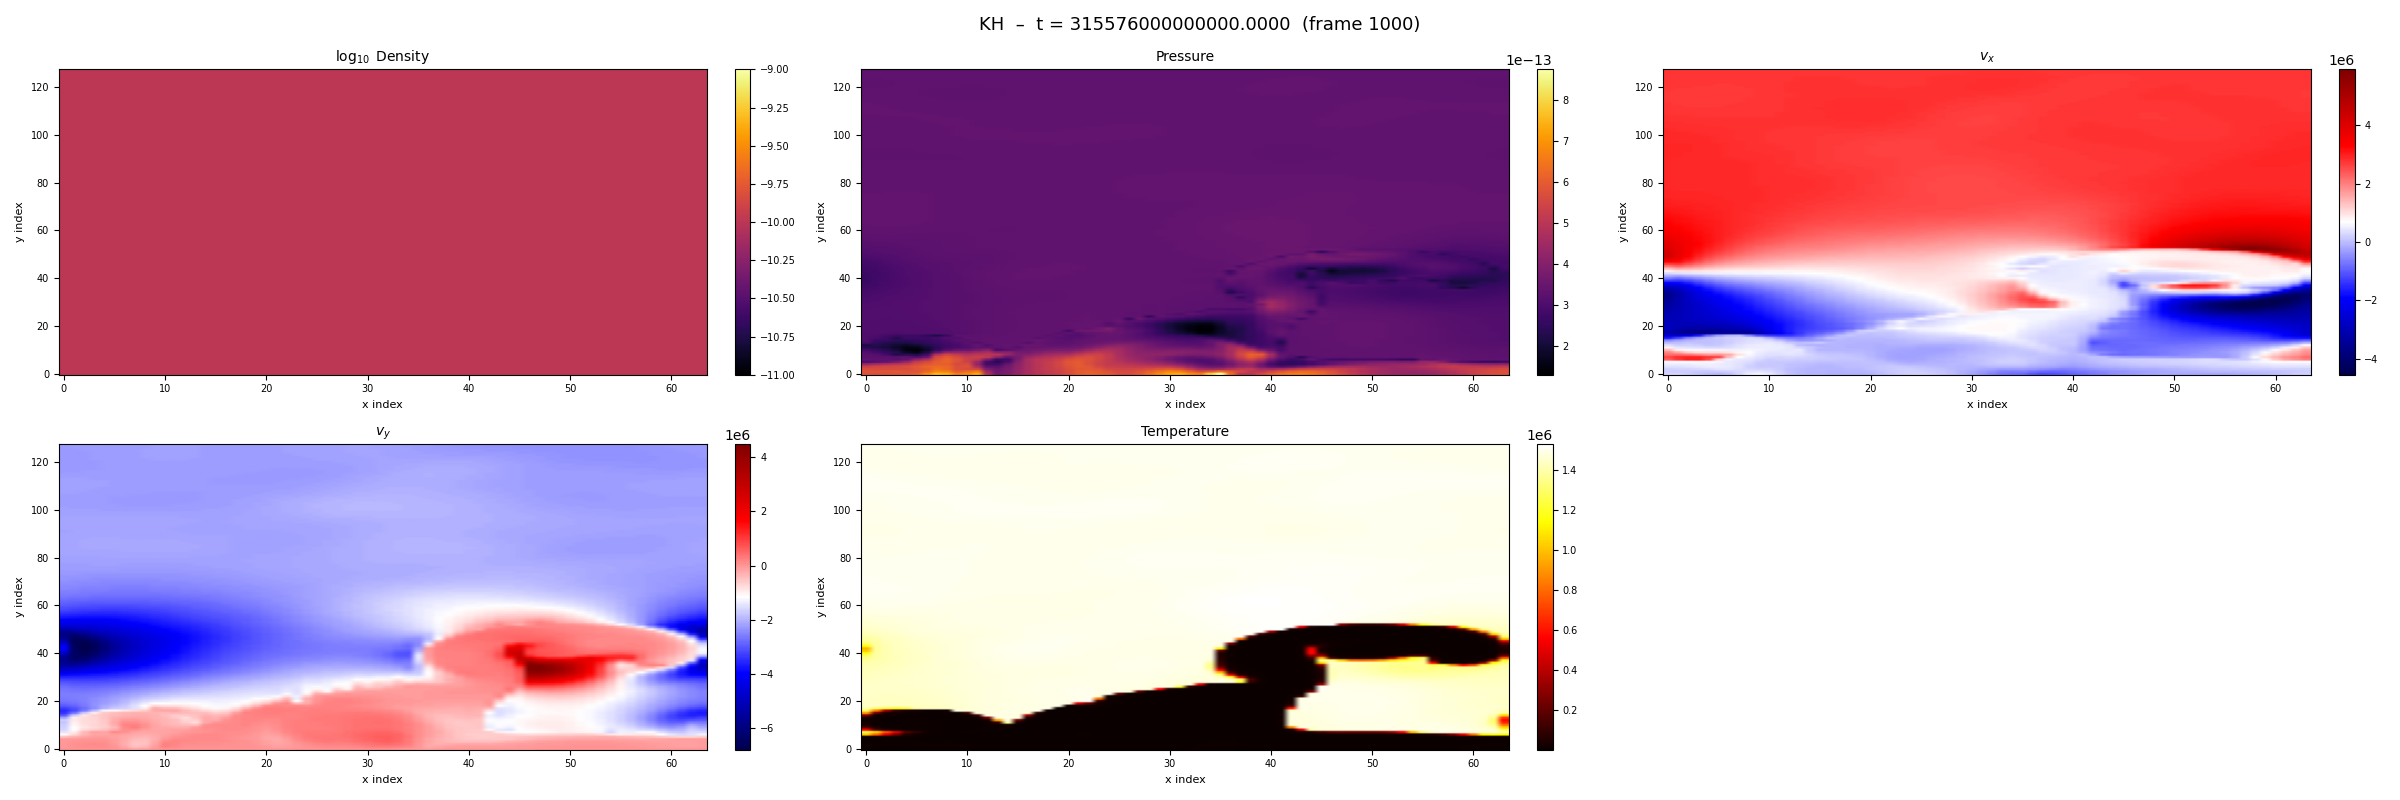

In [8]:
# ── Choose which frame to plot ────────────────────────────────────────────────
SNAPSHOT_FRAME = sim.frame_numbers[-1]   # last frame; change as needed

frame = sim.get_frame(SNAPSHOT_FRAME)
fields_to_show = [f for f in sim.fields_available if getattr(frame, f) is not None]

import math
ncols = math.ceil(math.sqrt(len(fields_to_show)))
nrows = math.ceil(len(fields_to_show) / ncols)

CMAPS = {
    "density":  "inferno",
    "pressure": "inferno",
    "velx":     "seismic",
    "vely":     "seismic",
    "velz":     "seismic",
    "bx":       "bwr",
    "by":       "bwr",
    "bz":       "bwr",
    "temperature": "hot",
}
TITLES = {
    "density":     r"$\log_{10}$ Density",
    "pressure":    "Pressure",
    "velx":        r"$v_x$",
    "vely":        r"$v_y$",
    "velz":        r"$v_z$",
    "bx":          r"$B_x$",
    "by":          r"$B_y$",
    "bz":          r"$B_z$",
    "temperature": r"Temperature",
}

fig, axes = plt.subplots(nrows, ncols, figsize=(8 * ncols, 4 * nrows), squeeze=False)
fig.suptitle(f"{sim.basename}  –  t = {frame.time:.4f}  (frame {frame.number})", fontsize=13)

# Hide unused axes
for idx in range(len(fields_to_show), nrows * ncols):
    r, c = divmod(idx, ncols)
    fig.delaxes(axes[r, c])

for idx, fname in enumerate(fields_to_show):
    r, c = divmod(idx, ncols)
    ax = axes[r, c]

    data = getattr(frame, fname)
    if fname == "density":
        data = np.log10(np.maximum(data, 1e-10))

    cmap = CMAPS.get(fname, "viridis")
    im = ax.imshow(data, cmap=cmap, origin="lower", aspect="auto")
    ax.set_title(TITLES.get(fname, fname), fontsize=10)
    ax.set_xlabel("x index", fontsize=8)
    ax.set_ylabel("y index", fontsize=8)
    ax.tick_params(labelsize=7)
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04).ax.tick_params(labelsize=7)

fig.tight_layout()
plt.show()

---
## 6 · Time-series analysis

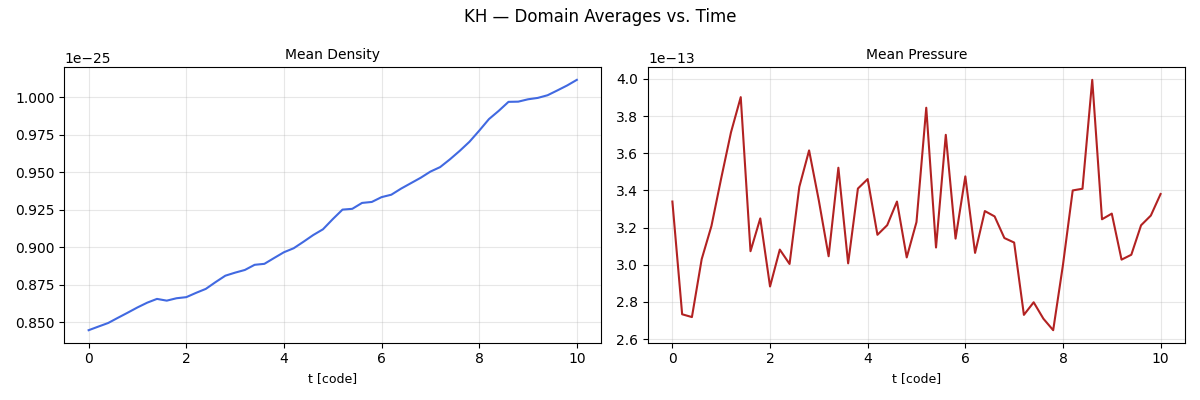

In [10]:
# ── Volume-averaged density and pressure vs. time ─────────────────────────────
# NOTE: This iterates over ALL frames and reads every file — may take a while.
# Reduce STEP to speed things up (skips frames).
STEP = max(1, sim.n_frames // 50)   # sample at most ~50 frames

sampled_nums  = sim.frame_numbers[::STEP]
sampled_times = times[::STEP]

mean_density  = []
mean_pressure = []

for num in sampled_nums:
    f = sim.get_frame(num)
    if f.density is not None:
        mean_density.append(float(np.mean(f.density)))
    if f.pressure is not None:
        mean_pressure.append(float(np.mean(f.pressure)))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle(f"{sim.basename} — Domain Averages vs. Time", fontsize=12)

if mean_density:
    axes[0].plot(sampled_times, mean_density, color="royalblue", lw=1.5)
    axes[0].set_xlabel("t [code]", fontsize=9)
    #axes[0].set_ylabel(r"$\langle \rho \rangle$ [code]", fontsize=9)
    axes[0].set_title("Mean Density", fontsize=10)
    axes[0].grid(True, alpha=0.3)

if mean_pressure:
    axes[1].plot(sampled_times, mean_pressure, color="firebrick", lw=1.5)
    axes[1].set_xlabel("t [code]", fontsize=9)
    #axes[1].set_ylabel(r"$\langle P \rangle$", fontsize=9)
    axes[1].set_title("Mean Pressure", fontsize=10)
    axes[1].grid(True, alpha=0.3)

fig.tight_layout()
plt.show()

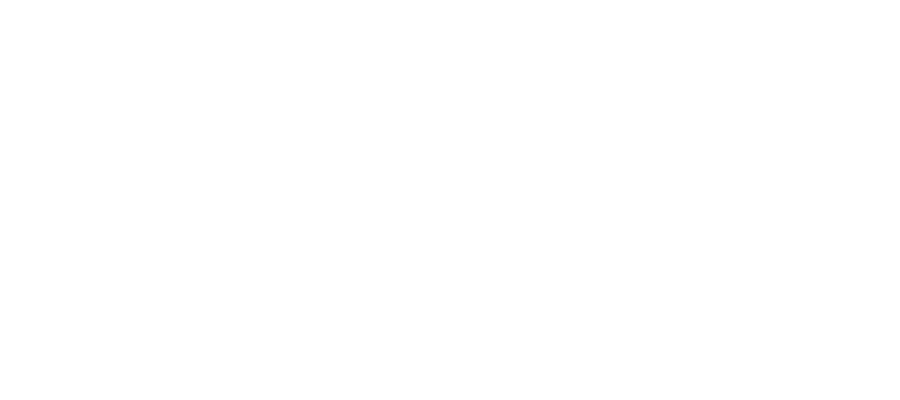

In [12]:
# ── Kinetic energy vs. time ───────────────────────────────────────────────────
ke_series = []

for num in sampled_nums:
    f = sim.get_frame(num)
    ke = 0.0
    if f.density is not None and f.velx is not None and f.vely is not None:
        ke = float(np.mean(0.5 * f.density * (f.velx**2 + f.vely**2)))
    ke_series.append(ke)

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(sampled_times, ke_series, color="darkorange", lw=1.5)
ax.set_xlabel("t [code]", fontsize=9)
#ax.set_ylabel(r"$\langle \frac{1}{2} \rho v^2 \rangle$ [code]", fontsize=9)
ax.set_title(f"{sim.basename} — Mean Kinetic Energy Density vs. Time", fontsize=10)
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

---
## 7 · Field accessor examples

In [13]:
# ── Various ways to access field data ────────────────────────────────────────

# By frame number (file-suffix integer)
first_rho = sim.density[sim.frame_numbers[0]]
last_rho  = sim.density[-1]   # negative index → last frame
print(f"density[first] shape : {first_rho.shape}")
print(f"density[-1]    shape : {last_rho.shape}")

# Nearest frame to a target time
mid_t = float(times[len(times) // 2])
rho_mid = sim.density.at_time(mid_t)
print(f"density.at_time({mid_t:.3f}) shape: {rho_mid.shape}")

# All frames in a time window
t0, t1 = float(times[0]), float(times[min(5, len(times)-1)])
window = sim.density.between(t0, t1)
print(f"density.between({t0:.3f}, {t1:.3f}) → {len(window)} frame(s)")

density[first] shape : (128, 64)
density[-1]    shape : (128, 64)
density.at_time(5.000) shape: (128, 64)
density.between(0.000, 0.050) → 6 frame(s)


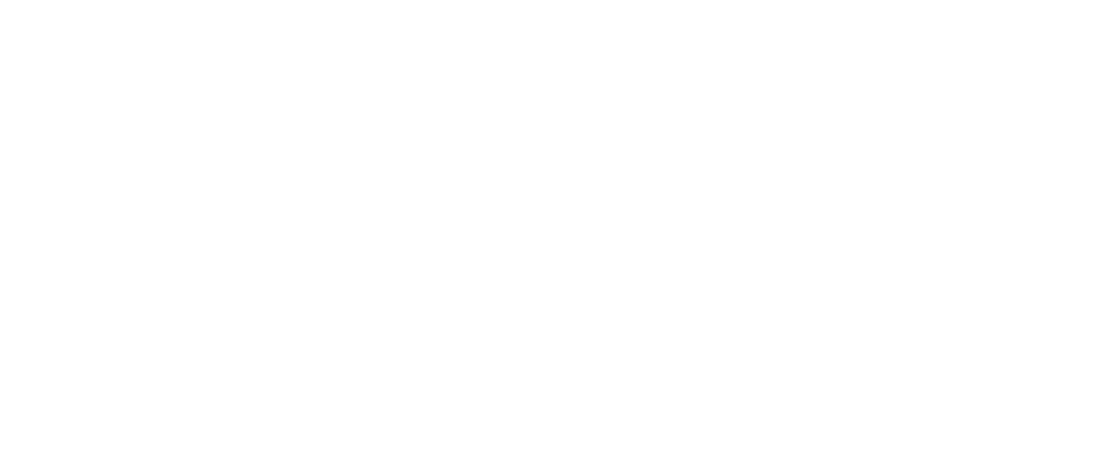

In [14]:
# ── Compare first vs last density ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
fig.suptitle(f"{sim.basename} — Density evolution (log₁₀)", fontsize=12)

for ax, arr, label in [
    (axes[0], first_rho, f"t = {times[0]:.4f}  (frame {sim.frame_numbers[0]})"),
    (axes[1], last_rho,  f"t = {times[-1]:.4f}  (frame {sim.frame_numbers[-1]})"),
]:
    im = ax.imshow(np.log10(np.maximum(arr, 1e-10)), cmap="inferno", origin="lower", aspect="auto")
    ax.set_title(label, fontsize=9)
    ax.tick_params(labelsize=7)
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04).ax.tick_params(labelsize=7)

fig.tight_layout()
plt.show()

---
## 8 · Interactive frame viewer

Uses **`ergane`'s `jupyter` backend** which wraps the matplotlib figure in
an `ipywidgets` UI with:
- **▶ Play** button — cycles through frames automatically
- **Frame slider** — manually scrub to any frame
- **Log scale toggle** — switches density display between linear and log₁₀
- **Colourmap dropdowns** — per-field colourmap selection

> **Note**: requires `ipywidgets` and `ipympl` (for `%matplotlib widget`).
> Install with: `pip install ipywidgets ipympl`

In [16]:
# ── Interactive viewer — all available fields ─────────────────────────────────
viz = sim.visualize(
    backend="jupyter",
    interval=3,            # ms between auto-play frames
)
print(viz)
viz.show()

<JupyterVisualization  sim='KH'  fields=['density', 'pressure', 'velx', 'vely', 'temperature']  n_frames=1001>


In [ ]:
# ── Interactive viewer — density + pressure only ──────────────────────────────
viz2 = sim.visualize(
    fields=["density", "pressure"],
    backend="jupyter",
    interval=200,
    figsize_per_panel=(6, 4.5),
)
viz2.show()

---
## 9 · Physical units (optional)

If you want field arrays in CGS units instead of code units, attach a `Units`
object.  All subsequent field accesses will return converted arrays.

In [ ]:
# ── Example: CGS unit system ──────────────────────────────────────────────────
# 1 code length = 1 pc, 1 code density = 1 proton mass/cc, 1 code velocity = 1 km/s
cgs = Units.cgs(
    length   = 3.086e18,   # cm  (1 parsec)
    density  = 1.67e-24,   # g/cm³  (1 proton mass/cc)
    velocity = 1.0e5,      # cm/s  (1 km/s)
    labels   = {
        "density":  "g cm⁻³",
        "pressure": "dyn cm⁻²",
        "velx":     "km s⁻¹",
        "vely":     "km s⁻¹",
    },
)

sim.set_units(cgs)
print(f"Units now: {sim.units}")
print(f"Density label: {sim.units.label('density')}")

rho_cgs = sim.density[-1]
print(f"Last frame density (CGS):  min={rho_cgs.min():.3e}  max={rho_cgs.max():.3e}")

# Reset to code units
sim.set_units(Units.code())
print(f"\nReset to: {sim.units}")

---
## 10 · Matplotlib animation export (optional)

Use the `matplotlib` backend to create a self-contained `FuncAnimation`
that can be saved to an MP4 / GIF without any ipywidgets dependency.

In [ ]:
# ── Save a matplotlib animation to disk ──────────────────────────────────────
# Uncomment the block below to run.

# SAVE_PATH = PROJECT_ROOT / "outputs" / f"{sim.basename}_animation.mp4"
# SAVE_PATH.parent.mkdir(parents=True, exist_ok=True)

# mpl_viz = sim.visualize(
#     fields=["density", "pressure"],
#     backend="matplotlib",
#     interval=80,
# )
# mpl_viz.ani.save(
#     str(SAVE_PATH),
#     writer="ffmpeg",
#     fps=15,
#     dpi=150,
# )
# print(f"Saved animation to: {SAVE_PATH}")

print("Uncomment the block above to save an MP4 animation.")